In [130]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
df= pd.read_csv("/german_cedit.csv", index_col=0)
print(df.columns)
df.head()

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [132]:
df_encoded= pd.get_dummies(df, columns=["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"], drop_first=True)
df_encoded.head()

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,good,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,bad,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,good,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,good,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,bad,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [133]:
x= df_encoded.drop(["Risk"], axis=1)
y= df_encoded["Risk"]

In [134]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [135]:
smote= SMOTE(random_state=42)
x_train_balanced, y_train_balanced= smote.fit_resample(x_train, y_train)
print("Class distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(y_train_balanced.value_counts())

Class distribution before SMOTE:
Risk
good    559
bad     241
Name: count, dtype: int64

Class distribution after SMOTE:
Risk
bad     559
good    559
Name: count, dtype: int64


In [137]:
model= RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(x_train_balanced, y_train_balanced)
predictions=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("/nClassification Report:\n", classification_report(y_test,predictions))

Accuracy: 0.64
/nClassification Report:
               precision    recall  f1-score   support

         bad       0.39      0.39      0.39        59
        good       0.74      0.74      0.74       141

    accuracy                           0.64       200
   macro avg       0.57      0.57      0.57       200
weighted avg       0.64      0.64      0.64       200



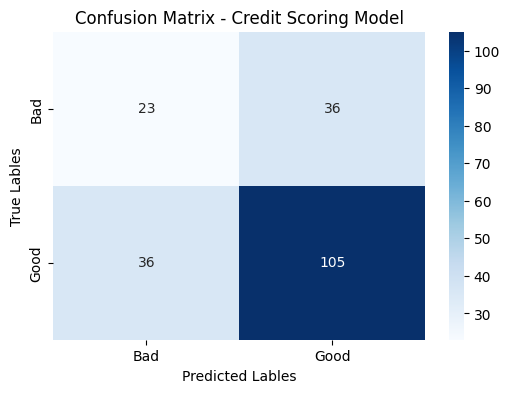

In [138]:
cm= confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"])
plt.xlabel("Predicted Lables")
plt.ylabel("True Lables")
plt.title("Confusion Matrix - Credit Scoring Model")
plt.show()

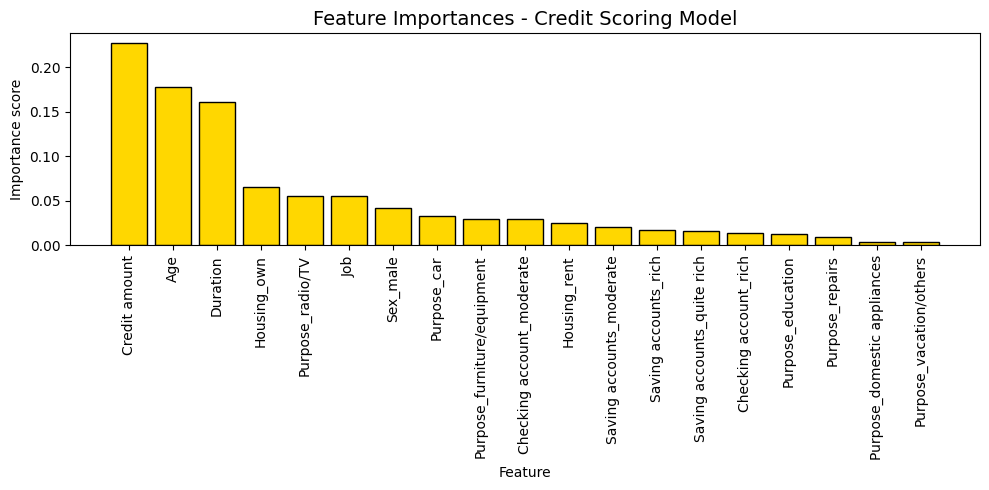

In [139]:
importances= model.feature_importances_
indices= np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.title("Feature Importances - Credit Scoring Model", fontsize=14)
plt.bar(range(x_train.shape[1]), importances[indices], align="center", color="gold", edgecolor="black")
plt.xticks(range(x_train.shape[1]), x_train.columns[indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()